In [1]:
import QuantLib as ql
import numpy as np
import matplotlib.pyplot as plt

In [2]:
day_count = ql.Actual365Fixed()
calendar  = ql.NullCalendar()

calculation_date = ql.Date(22, 11, 2021)
spot = 57407.27

ql.Settings.instance().evaluationDate = calculation_date

risk_free_rate = [0.00091249886, 0.00091249886, 0.00141713916, 0.00178991217, 0.00308713517] # 2021/11/02 0D 1D 3M 6M 12M
risk_free_rate_date = [ql.Date(22, 11, 2021), ql.Date(23, 11, 2021), ql.Date(23, 2, 2022), ql.Date(23, 5, 2022), ql.Date(23, 11, 2022)]
zero_curve = ql.YieldTermStructureHandle(ql.ZeroCurve(risk_free_rate_date, risk_free_rate, day_count, calendar))

dividend_rate = 0.0
dividend_ts = ql.YieldTermStructureHandle(ql.FlatForward(calculation_date, dividend_rate, day_count))

In [3]:
# Dummy parameters for construct Heston model
v0 = 0.01; kappa = 0.20; theta = 0.02; rho = -0.75; sigma = 0.50 # cookbook
# v0 = 0.1; kappa = 0.1; theta = 0.1; rho = -0.1; sigma = 0.1
HestonProcess = ql.HestonProcess(zero_curve, dividend_ts, ql.QuoteHandle(ql.SimpleQuote(spot)), v0, kappa, theta, sigma, rho)
HestonModel = ql.HestonModel(HestonProcess)
AHE = ql.AnalyticHestonEngine(HestonModel)

In [4]:
# 合約到期日
expiration_dates = [ql.Date(31, 12, 2021), ql.Date(25, 3, 2022), ql.Date(24, 6, 2022)]
# 合約標的
strikes = [30000, 40000, 50000, 60000, 70000, 80000, 90000, 100000, 120000]
# 合約標的的隱含波動率
data = [[1.1340, 0.9864, 0.8955, 0.8344, 0.8328, 0.8692, 0.9165, 0.9808, 1.0735],
        [1.0149, 0.9587, 0.9241, 0.9046, 0.9000, 0.9055, 0.9177, 0.9338, 0.9684],
        [0.9697, 0.9399, 0.9193, 0.9098, 0.9073, 0.9089, 0.9128, 0.9181, 0.9497]]

# Implied Volatility Matrix
implied_vols = ql.Matrix(len(strikes), len(expiration_dates))
for i in range(implied_vols.rows()):
    for j in range(implied_vols.columns()):
        implied_vols[i][j] = data[j][i]
        
black_var_surface = ql.BlackVarianceSurface(calculation_date, calendar, expiration_dates, strikes, implied_vols, day_count)

In [5]:
heston_helpers = []
black_var_surface.setInterpolation("bicubic")
maturity_idx = 1
date = expiration_dates[maturity_idx]

for j, s in enumerate(strikes):
    t = (date - calculation_date)
    period = ql.Period(t, ql.Days)
    vol = data[maturity_idx][j]
    helper = ql.HestonModelHelper(period, calendar, spot, s, 
                                  ql.QuoteHandle(ql.SimpleQuote(vol)),
                                  zero_curve, 
                                  dividend_ts)
    helper.setPricingEngine(AHE)
    heston_helpers.append(helper)
    
HestonModel.calibrate(heston_helpers, ql.LevenbergMarquardt(), ql.EndCriteria(500, 50, 1.0e-8, 1.0e-8, 1.0e-8))

theta, kappa, sigma, rho, v0 = HestonModel.params()
print("theta = %f, kappa = %f, sigma = %f, rho = %f, v0 = %f" % (theta, kappa, sigma, rho, v0))

theta = 1.939497, kappa = 3.690765, sigma = 4.153086, rho = -0.119265, v0 = 0.243510


In [6]:
HestonProcess = ql.HestonProcess(zero_curve, dividend_ts, ql.QuoteHandle(ql.SimpleQuote(spot)), v0, kappa, theta, sigma, rho)
HestonModel = ql.HestonModel(HestonProcess)
AHE = ql.AnalyticHestonEngine(HestonModel)

In [7]:
def HestonModel_MonteCarloSimulation (S0, mu, v0, kappa, theta, sigma, rho, step):
    
    dt = 1/365

    MU  = np.array([0, 0])
    COV = np.matrix([[1, rho], [rho, 1]])
    W   = np.random.multivariate_normal(MU, COV, step)
    W_S = W[:,0]
    W_v = W[:,1]

    vt    = np.zeros(step)
    vt[0] = v0
    St    = np.zeros(step)
    St[0] = S0

    for t in range(1, step):
        vt[t] = np.maximum(vt[t-1] + kappa*(theta - vt[t-1])*dt + sigma*np.sqrt(np.abs(vt[t-1])*dt)*W_v[t], 0)
        St[t] = St[t-1] + mu*St[t-1]*dt + np.sqrt(np.abs(vt[t-1])*dt)*St[t-1]*W_S[t]
    return St

In [21]:
# 參數設定
maturity = ql.Date(25, 3, 2022)
step = maturity - calculation_date
T = step/365
path = 20000
r = zero_curve.zeroRate(maturity, day_count, ql.Continuous).rate()
discount_rate = np.exp(-r*T)

avg_err = 0.74%


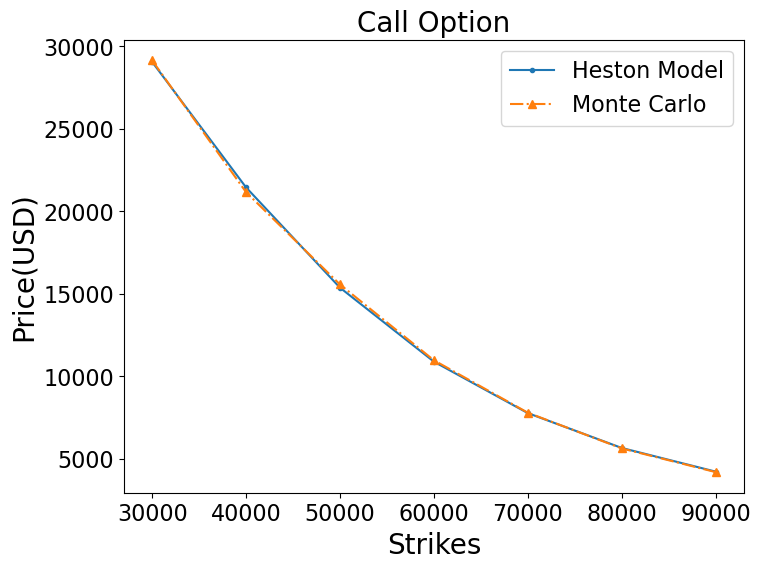

In [44]:
# 退化的 boundary option vs vanilla option
bitcoin_strikes = [30000, 40000, 50000, 60000, 70000, 80000, 90000]
boundary = 0

simulation = []
model = []
avg_err = 0
for i in range(len(bitcoin_strikes)):
    CT_avg = 0
    strike = bitcoin_strikes[i]
    for j in range (path):
        spot_path = HestonModel_MonteCarloSimulation (spot, r, v0, kappa, theta, sigma, rho, step)
        if (spot_path < boundary).any():
            CT = 0
        else:
            if spot_path[-1] > strike:
                CT = (spot_path[-1] - strike)*discount_rate
            else:
                CT = 0  
        CT_avg = CT_avg + CT

    CT_avg = CT_avg/path
    simulation.append(CT_avg)
    europeanExer = ql.EuropeanExercise(maturity)
    vanillaPayoff = ql.PlainVanillaPayoff(ql.Option.Call, strike)
    anEuroOption = ql.EuropeanOption(vanillaPayoff, europeanExer)
    anEuroOption.setPricingEngine(AHE)
    model.append(anEuroOption.NPV())
    avg_err = avg_err + np.abs(round((CT_avg/anEuroOption.NPV() - 1.0)*100, 2))/len(bitcoin_strikes)

print("avg_err = " + str(round(avg_err, 2)) + "%",)

fig = plt.figure(dpi = 100, linewidth = 2)
fig.set_size_inches(8, 6)
    
plt.plot(bitcoin_strikes, model, '.-', label = 'Heston Model')
plt.plot(bitcoin_strikes, simulation, '^-.', label = 'Monte Carlo')

plt.title("Call Option", fontsize = 20)

plt.xticks(fontsize = 16)
plt.xlabel("Strikes", fontsize = 20)

plt.yticks(fontsize = 16)
plt.ylabel("Price(USD)", fontsize = 20)

plt.legend(loc = "best", fontsize = 16)

plt.show()

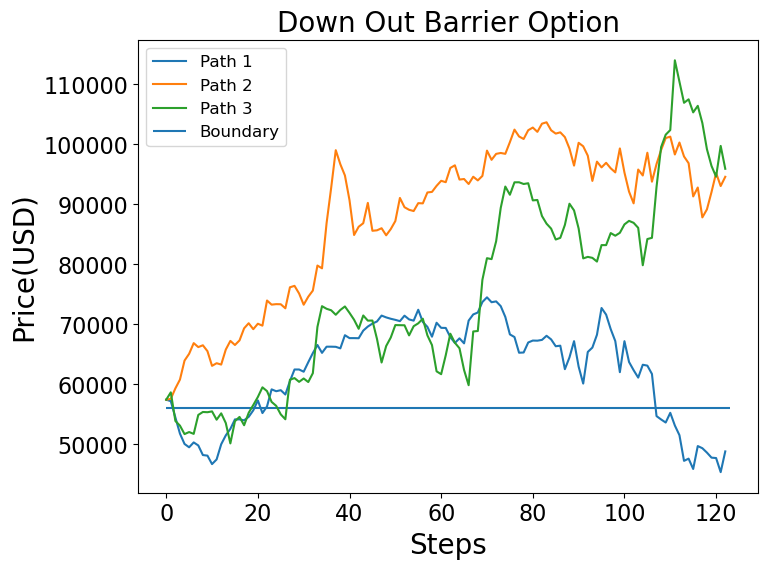

In [80]:
# Heston Model 隨機過程
fig = plt.figure(dpi = 100, linewidth = 2)
fig.set_size_inches(8, 6)
    
for i in range(3):
    spot_path = HestonModel_MonteCarloSimulation (spot, dividend_rate, v0, kappa, theta, sigma, rho, step)
    plt.plot(range(step), spot_path, label = 'Path ' + str(i+1))

plt.title("Down Out Barrier Option", fontsize = 20)

plt.hlines(56000, xmin = 0, xmax = len(spot_path), label = 'Boundary')

plt.xticks(fontsize = 16)
plt.xlabel("Steps", fontsize = 20)

plt.yticks(fontsize = 16)
plt.ylabel("Price(USD)", fontsize = 20)

plt.legend(loc = "upper left", fontsize = 12)

plt.show()

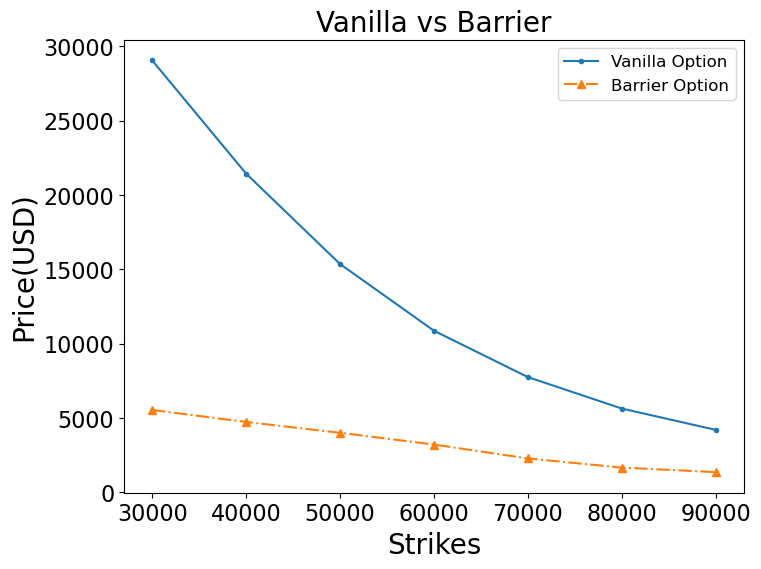

In [24]:
# Vanilla vs Barrier
bitcoin_strikes = [30000, 40000, 50000, 60000, 70000, 80000, 90000]
boundary = 55000

simulation = []
model = []
for i in range(len(bitcoin_strikes)):
    CT_avg = 0
    strike = bitcoin_strikes[i]
    for j in range (path):
        spot_path = HestonModel_MonteCarloSimulation (spot, r, v0, kappa, theta, sigma, rho, step)
        if (spot_path < boundary).any():
            CT = 0
        else:
            if spot_path[-1] > strike:
                CT = (spot_path[-1] - strike)*discount_rate
            else:
                CT = 0  
        CT_avg = CT_avg + CT

    CT_avg = CT_avg/path
    simulation.append(CT_avg)
    europeanExer = ql.EuropeanExercise(maturity)
    vanillaPayoff = ql.PlainVanillaPayoff(ql.Option.Call, strike)
    anEuroOption = ql.EuropeanOption(vanillaPayoff, europeanExer)
    anEuroOption.setPricingEngine(AHE)
    model.append(anEuroOption.NPV())
    
fig = plt.figure(dpi = 100, linewidth = 2)
fig.set_size_inches(8, 6)
    
plt.plot(bitcoin_strikes, model, '.-', label = 'Vanilla Option')
plt.plot(bitcoin_strikes, simulation, '^-.', label = 'Barrier Option')

plt.title("Vanilla vs Barrier", fontsize = 20)

plt.xticks(fontsize = 16)
plt.xlabel("Strikes", fontsize = 20)

plt.yticks(fontsize = 16)
plt.ylabel("Price(USD)", fontsize = 20)

plt.legend(loc = "best", fontsize = 12)

plt.show()

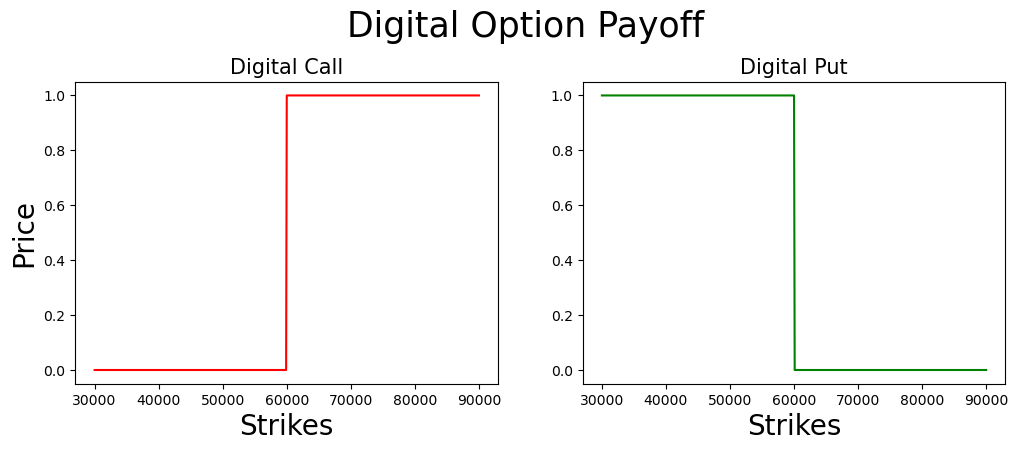

In [61]:
def binary_call_payoff(K, S_T):
    if S_T >= K:
        return 1.0
    else:
        return 0.0
    
def binary_put_payoff(K, S_T):
    if S_T <= K:
        return 1.0
    else:
        return 0.0

bitcoin_strikes = np.linspace(30000, 90000, num = (90000 - 30000)//100 + 1, dtype = np.int32).tolist()
bitcoin_strikes_xlabel = [30000, 40000, 50000, 60000, 70000, 80000, 90000]

digital_call = []
digital_put = []
for i in bitcoin_strikes:
    digital_call.append(binary_call_payoff(60000, i))
    digital_put.append(binary_put_payoff(60000, i))
    

fig = plt.figure(dpi = 100, linewidth = 2)
fig.set_size_inches(12, 4)

ax1 = plt.subplot(121)
ax1.plot(bitcoin_strikes, digital_call, 'r')
plt.title("Digital Call", fontsize = 15)

plt.xlabel("Strikes", fontsize = 20)

plt.ylabel("Price", fontsize = 20)

ax2 = plt.subplot(122)
ax2.plot(bitcoin_strikes, digital_put, 'g')
plt.title("Digital Put", fontsize = 15)

plt.xlabel("Strikes", fontsize = 20)


# plt.xticks(fontsize = 16)
# plt.xlabel("Times", fontsize = 20)

# plt.yticks(fontsize = 16)
# plt.ylabel("Price(USD)", fontsize = 20)

plt.suptitle("Digital Option Payoff", fontsize = 25, y = 1.06)

plt.show()

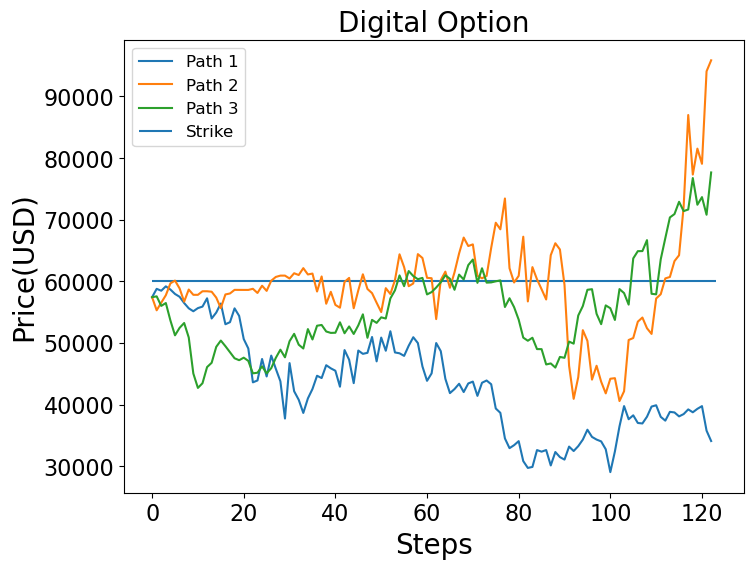

In [99]:
# Heston Model 隨機過程
fig = plt.figure(dpi = 100, linewidth = 2)
fig.set_size_inches(8, 6)
    
for i in range(3):
    spot_path = HestonModel_MonteCarloSimulation (spot, dividend_rate, v0, kappa, theta, sigma, rho, step)
    plt.plot(range(step), spot_path, label = 'Path ' + str(i+1))

plt.title("Digital Option", fontsize = 20)

plt.hlines(60000, xmin = 0, xmax = len(spot_path), label = 'Strike')

plt.xticks(fontsize = 16)
plt.xlabel("Steps", fontsize = 20)

plt.yticks(fontsize = 16)
plt.ylabel("Price(USD)", fontsize = 20)

plt.legend(loc = "upper left", fontsize = 12)

plt.show()

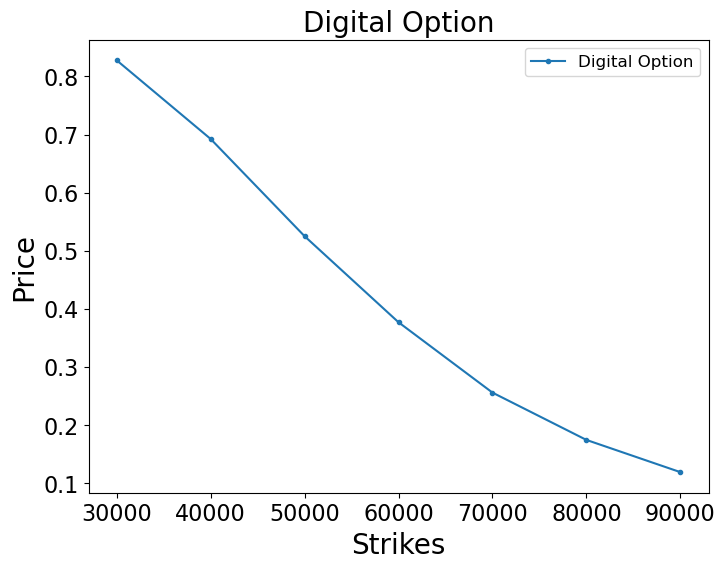

In [62]:
# Digital Option
bitcoin_strikes = [30000, 40000, 50000, 60000, 70000, 80000, 90000]

simulation = []
for i in range(len(bitcoin_strikes)):
    CT_avg = 0
    strike = bitcoin_strikes[i]
    for j in range (path):
        spot_path = HestonModel_MonteCarloSimulation (spot, r, v0, kappa, theta, sigma, rho, step)
        if spot_path[-1] > strike:
            CT_avg = CT_avg + 1

    CT_avg = CT_avg/path
    simulation.append(CT_avg)
    
fig = plt.figure(dpi = 100, linewidth = 2)
fig.set_size_inches(8, 6)
    
plt.plot(bitcoin_strikes, simulation, '.-', label = 'Digital Option')

plt.title("Digital Option", fontsize = 20)

plt.xticks(fontsize = 16)
plt.xlabel("Strikes", fontsize = 20)

plt.yticks(fontsize = 16)
plt.ylabel("Price", fontsize = 20)

plt.legend(loc = "best", fontsize = 12)

plt.show()